# 📊 Exploratory Data Analysis (EDA)
## Brazilian E-Commerce — Olist Dataset
**Author:** Nayla | **Dataset:** Olist (Kaggle)

## 1. Library & Dependencies
Mengimport seluruh library yang dibutuhkan untuk analisis data.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset
Membaca 6 file CSV dari dataset Olist yang terdiri dari informasi orders, customers, products, payments, dan reviews.

In [38]:
orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

print(f"Total orders: {len(orders):,}")
print(f"Total customers: {customers['customer_unique_id'].nunique():,}")

Total orders: 99,441
Total customers: 96,096


## 3. Missing Values & Duplicate Check
Mengidentifikasi kualitas data — missing values dan duplikat pada setiap tabel sebelum proses cleaning dilakukan.

In [37]:
for name, df in [('orders', orders), ('items', items), 
                  ('customers', customers), ('payments', payments)]:
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    print(f"\n--- {name} ---")
    print(pd.DataFrame({'missing': missing, '%': pct})[missing > 0])

print(f"\nDuplikat orders: {orders.duplicated().sum()}")


--- orders ---
                               missing     %
order_approved_at                  160  0.16
order_delivered_carrier_date      1783  1.79
order_delivered_customer_date     2965  2.98

--- items ---
Empty DataFrame
Columns: [missing, %]
Index: []

--- customers ---
Empty DataFrame
Columns: [missing, %]
Index: []

--- payments ---
Empty DataFrame
Columns: [missing, %]
Index: []

Duplikat orders: 0


## 4. Distribusi Awal Data
Visualisasi awal untuk memahami distribusi status pesanan dan tren jumlah pesanan per bulan.

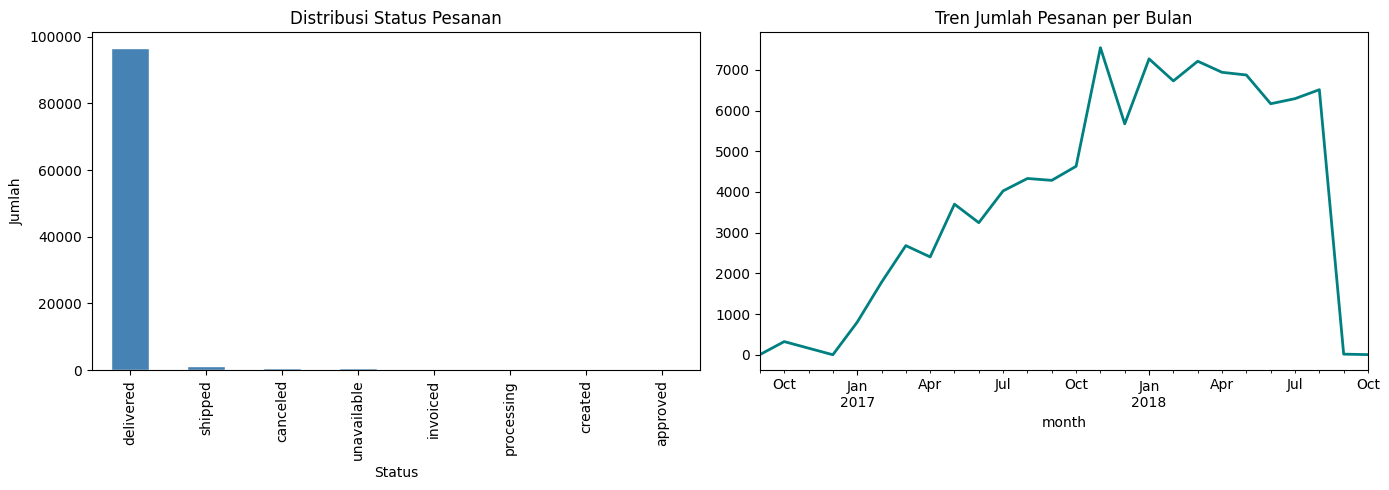

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orders['order_status'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Status Pesanan')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah')

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size()
monthly.plot(ax=axes[1], color='teal', linewidth=2)
axes[1].set_title('Tren Jumlah Pesanan per Bulan')

plt.tight_layout()
plt.savefig('../output/charts/01_eda_overview.png', dpi=150)
plt.show()